# Conservative sentiment preprocessing

Preserve original text and sentiment cues; apply one fixed stateless function to each official split. No learned features, stopword filtering, stemming, lemmatization or resplitting. Defaults retain emoji, punctuation, repeated characters and contractions; optional transformations are demonstrated on illustrative examples only.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'config.py').is_file())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from src.config import RAW_DATA_DIR, FIGURES_DIR
from src.data_loader import load_csv
from IPython.display import display, Image
train = load_csv(RAW_DATA_DIR / 'tweet_eval_train.csv')

In [2]:
import pandas as pd
from src.preprocessing import (clean_text, preprocess_dataframe, PreprocessingConfig,
    remove_urls, handle_mentions, handle_hashtags, handle_emojis, handle_html,
    normalize_whitespace, normalize_unicode, normalize_repeated_characters)
examples = ["@Apple WTF 😡😡 battery dies in 2 hrs!!! https://abc.com #iPhone",
            "I DON'T like this phone!!!", "Great phone 😍 #AmazingCamera",
            "  Hello\t world  ", "I can’t recommend this", "sooooo good!!!"]
display(pd.DataFrame({'text': examples, 'clean_text': [clean_text(t) for t in examples]}))

,text,clean_text
0,@Apple WTF 😡😡 battery dies in 2 hrs!!! https:/...,wtf 😡😡 battery dies in 2 hrs!!! iphone
1,I DON'T like this phone!!!,i don't like this phone!!!
2,Great phone 😍 #AmazingCamera,great phone 😍 amazingcamera
3,Hello\t world,hello world
4,I can’t recommend this,i can't recommend this
5,sooooo good!!!,sooooo good!!!


In [3]:
display({
    'URL': remove_urls('See https://example.com now!'),
    'mention': handle_mentions('Thanks @Apple'),
    'hashtag': handle_hashtags('#AmazingCamera'),
    'emoji_preserve': handle_emojis('😍 😡 ❤️'),
    'emoji_text_optional': handle_emojis('😍', 'demojize'),
    'HTML': handle_html('<b>Good</b> &amp; nice'),
    'whitespace': normalize_whitespace('  hello   world  '),
    'unicode': normalize_unicode('cafe\u0301'),
    'repeat_optional': normalize_repeated_characters('sooooo good!!!'),
    'negation': clean_text("No, I don't like it. Never again!")})
assert "don't" in clean_text("I DON'T like this phone!!!")
assert '😡' in clean_text(examples[0])

{'URL': 'See   now!',
 'mention': 'Thanks  ',
 'hashtag': 'AmazingCamera',
 'emoji_preserve': '😍 😡 ❤️',
 'emoji_text_optional': ' smiling_face_with_heart-eyes ',
 'HTML': ' Good  & nice',
 'whitespace': 'hello world',
 'unicode': 'café',
 'repeat_optional': 'soo good!!!',
 'negation': "no, i don't like it. never again!"}

## TRAIN transformation and post-cleaning validation
The original frame and optional metadata are preserved. Missing input becomes empty clean text and is flagged by validation; the pipeline blocks unusable rows rather than dropping benchmark records.

{'critical_errors': {},
 'warnings': {'duplicate_rows': 26, 'duplicate_text': 43},
 'counts': {'rows': 45615,
  'missing_values': {'text': 0, 'sentiment': 0, 'split': 0, 'clean_text': 0},
  'duplicate_rows': 26,
  'null_text': 0,
  'non_string_text': 0,
  'blank_text': 0,
  'duplicate_text': 43,
  'short_text': 0,
  'long_text': 0}}

,text,sentiment,split,clean_text
0,"""QT @user In the original draft of the 7th boo...",positive,train,"""qt in the original draft of the 7th book, rem..."
1,"""Ben Smith / Smith (concussion) remains out of...",neutral,train,"""ben smith / smith (concussion) remains out of..."
2,Sorry bout the stream last night I crashed out...,neutral,train,sorry bout the stream last night i crashed out...
3,Chase Headley's RBI double in the 8th inning o...,neutral,train,chase headley's rbi double in the 8th inning o...
4,@user Alciato: Bee will invest 150 million in ...,positive,train,alciato: bee will invest 150 million in januar...


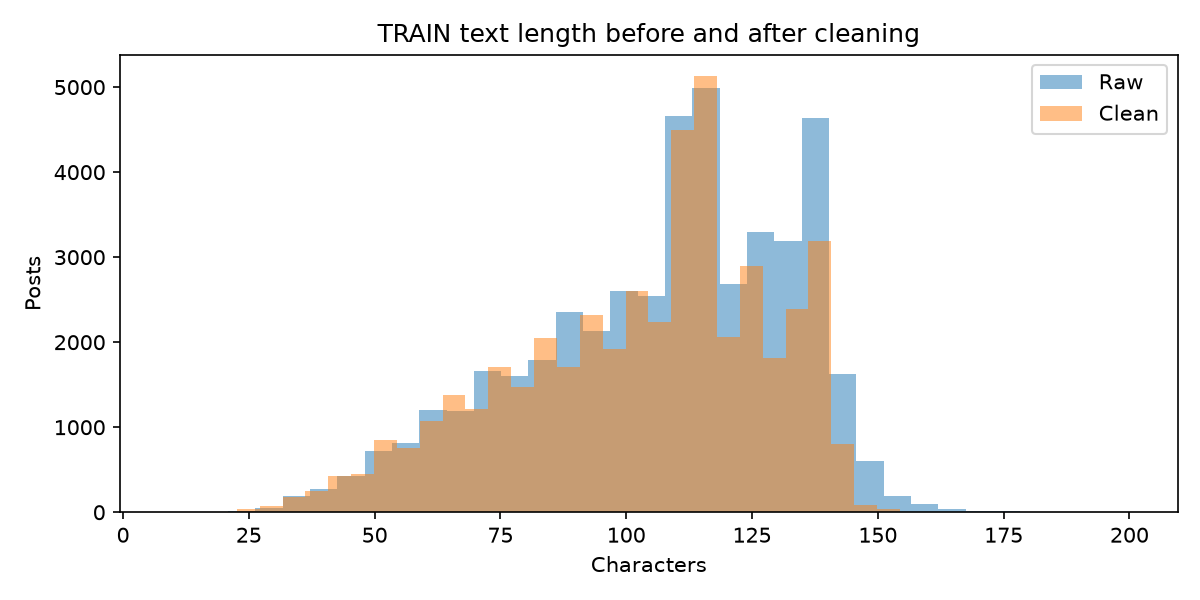

In [4]:
from src.data_validation import validate_dataframe, require_valid
from src.eda import plot_cleaning_lengths
processed = preprocess_dataframe(train)
quality = validate_dataframe(processed, 'train', text_column='clean_text')
require_valid(quality)
display(quality)
display(processed.head(5))
plot_cleaning_lengths(processed)
display(Image(filename=str(FIGURES_DIR / 'train_cleaning_lengths.png')))

## Generate all processed splits
This uses the same deterministic configuration for every split, verifies original text and label preservation, and reloads outputs. Test integrity is checked mechanically; test examples and class statistics are not displayed.

In [5]:
from src.pipeline import run_phase1
result = run_phase1(root)
display({name: {'rows': item['rows'], 'removed_rows': item['removed_rows']} for name, item in result['outputs'].items()})

{'train': {'rows': 45615, 'removed_rows': 0},
 'validation': {'rows': 2000, 'removed_rows': 0},
 'test': {'rows': 12284, 'removed_rows': 0}}

## Modeling contract
Load train_clean.csv for fitting features/models and validation_clean.csv for selection. Keep test_clean.csv locked until final evaluation. Default TF-IDF tokenization may discard emoji/punctuation and split contractions; design that future tokenizer with TRAIN and validate on VALIDATION. No modeling is implemented here.